In [1]:
import sys, os

import numpy as np
from umap import UMAP
import time
import torch
import matplotlib.pyplot as plt
import pandas as pd  
import scanpy as sc
import scipy.sparse as sps
import scipy.io as sio
# import scipy.sparse as sp
from os.path import join
import h5py
import warnings
import gc

import scmomat 

plt.rcParams["font.size"] = 10
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/setuptools_scm/_integration/setuptools.py:30: RuntimeWarning: 
ERROR: setuptools==59.5.0 is used in combination with setuptools_scm>=8.x

Your build configuration is incomplete and previously worked by accident!
setuptools_scm requires setuptools>=61

Suggested workaround if applicable:
 - migrating from the deprecated setup_requires mechanism to pep517/518
   and using a pyproject.toml to declare build dependencies
   which are reliably pre-installed before running the build tools

  warnings.warn(


In [2]:
def set_col2cat(ad, cols=[]):
    for col in cols:
        ad.obs[col] = ad.obs[col].astype('category')

def unify_colors(queries, color_key, ref_color_dict):
    for q in queries:
        q.obs[color_key] = q.obs[color_key].astype('category')
        q.uns[f'{color_key}_colors'] = [ref_color_dict[_] for _ in q.obs[color_key].cat.categories]
    return queries

def get_umap(ad, use_reps=[]):
    for use_rep in use_reps:
        umap_add_key = f'{use_rep}_umap'
        sc.pp.neighbors(ad, use_rep=use_rep, n_neighbors=15)
        sc.tl.umap(ad)
        ad.obsm[umap_add_key] = ad.obsm['X_umap']
    return ad

def wrap_warn_plot(adata, basis, color, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        sc.pl.embedding(adata, basis=basis, color=color, **kwargs)

def wrap_warn_comp_plot(ads, basis, colors, figw=5, figh=4, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i, color in enumerate(colors):
            _, axes = plt.subplots(1, len(ads), figsize=(figw*len(ads), figh))
            for j, ad in enumerate(ads):
                sc.pl.embedding(ad, basis=basis, color=color, ax=axes[j], show=False, **kwargs)
            plt.show()

In [3]:
def split_ob(ads, ad_ref, ob='obs', key='emb2'):
    len_ads = [_.n_obs for _ in ads]
    if ob=='obsm':
        split_obsms = np.split(ad_ref.obsm[key], np.cumsum(len_ads[:-1]))
        for ad, v in zip(ads, split_obsms):
            ad.obsm[key] = v
    else:
        split_obs = np.split(ad_ref.obs[key].to_list(), np.cumsum(len_ads[:-1]))
        for ad, v in zip(ads, split_obs):
            ad.obs[key] = v
    
def subset_ad(ad, subset_index):
    ad = ad[subset_index].copy()
    return ad

def set_spatial(ad):
    ad.obsm['spatial'] = ad.obs[['array_row', 'array_col']].values
    ad.obsm['spatial'] = ad.obsm['spatial'][:, ::-1]
    ad.obsm['spatial'][:, 1] = -1 * ad.obsm['spatial'][:, 1]
    return ad

### load dataset

In [4]:
data_dir = '../../../data/processed/Embryo'

ad_sra_rna = sc.read_h5ad(join(data_dir, 'SRA/ad_rna.h5ad'))
ad_sra_atac = sc.read_h5ad(join(data_dir, 'SRA/ad_atac.h5ad'))

ad_mux2_27ac = sc.read_h5ad(join(data_dir, 'Mux2/ad_h3k27ac.h5ad'))
ad_mux2_27me = sc.read_h5ad(join(data_dir, 'Mux2/ad_h3k27me3.h5ad'))

ad_mux4_rna = sc.read_h5ad(join(data_dir, 'Mux4/ad_rna.h5ad'))
ad_mux4_atac = sc.read_h5ad(join(data_dir, 'Mux4/ad_atac.h5ad'))
ad_mux4_4me3 = sc.read_h5ad(join(data_dir, 'Mux4/ad_h3k4me3.h5ad'))
ad_mux4_27me = sc.read_h5ad(join(data_dir, 'Mux4/ad_h3k27me3.h5ad'))

ad_sat_atac = sc.read_h5ad(join(data_dir, 'SAT/ad_atac.h5ad'))
ad_cut_27ac = sc.read_h5ad(join(data_dir, 'Cut-H3K27ac/ad_h3k27ac.h5ad'))
ad_cut_4me3 = sc.read_h5ad(join(data_dir, 'Cut-H3K4me3/ad_h3k4me3.h5ad'))
ad_cut_27me = sc.read_h5ad(join(data_dir, 'Cut-H3K27me3/ad_h3k27me3.h5ad'))

In [5]:
ad_rna_all = sc.concat([ad_sra_rna, ad_mux4_rna])
sc.pp.highly_variable_genes(ad_rna_all, flavor='seurat_v3', n_top_genes=10000, batch_key='Slice')
hvg_names = ad_rna_all.var.query('highly_variable').index.to_numpy()

ad_atac_all = sc.concat([ad_sra_atac, ad_mux4_atac, ad_sat_atac])
sc.pp.highly_variable_genes(ad_atac_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Slice')
hvp_names = ad_atac_all.var.query('highly_variable').index.to_numpy()

ad_27me_all = sc.concat([ad_mux2_27me, ad_mux4_27me, ad_cut_27me])
sc.pp.highly_variable_genes(ad_27me_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Slice')
hv27me_names = ad_27me_all.var.query('highly_variable').index.to_numpy()

ad_4me3_all = sc.concat([ad_mux4_4me3, ad_cut_4me3])
sc.pp.highly_variable_genes(ad_4me3_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Slice')
hv4me3_names = ad_4me3_all.var.query('highly_variable').index.to_numpy()

ad_27ac_all = sc.concat([ad_mux2_27ac, ad_cut_27ac])
sc.pp.highly_variable_genes(ad_27ac_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Slice')
hv27ac_names = ad_27ac_all.var.query('highly_variable').index.to_numpy()

<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 216 from C header, got 232 from PyObject


### prepare count inputs

In [6]:
counts_rnas = []
for adi in [ad_sra_rna, None, ad_mux4_rna, None, None, None, None]:
    if adi is not None:
        count = scmomat.preprocess(
            adi[:, hvg_names].X.A if sps.issparse(adi.X) else adi[:, hvg_names].X,
            modality = "RNA", log = False
        )
        counts_rnas.append(count)
    else:
        counts_rnas.append(None)

# ATAC
counts_atacs = []
for adi in [ad_sra_atac, None, ad_mux4_atac, ad_sat_atac, None, None, None]:
    if adi is not None:
        count = scmomat.preprocess(
            adi[:, hvp_names].X.A if sps.issparse(adi.X) else adi[:, hvp_names].X,
            modality = "ATAC", log = False
        )
        counts_atacs.append(count)
    else:
        counts_atacs.append(None)

# H3K4me3
counts_h3k4me3s = []
for adi in [None, None, ad_mux4_4me3, None, ad_cut_4me3, None, None]:
    if adi is not None:
        count = scmomat.preprocess(
            adi[:, hv4me3_names].X.A if sps.issparse(adi.X) else adi[:, hv4me3_names].X,
            modality = "ATAC", log = False
        )
        counts_h3k4me3s.append(count)
    else:
        counts_h3k4me3s.append(None)

# H3K27ac
counts_h3k27acs = []
for adi in [None, ad_mux2_27ac, None, None, None, ad_cut_27ac, None]:
    if adi is not None:
        count = scmomat.preprocess(
            adi[:, hv27ac_names].X.A if sps.issparse(adi.X) else adi[:, hv27ac_names].X,
            modality = "ATAC", log = False
        )
        counts_h3k27acs.append(count)
    else:
        counts_h3k27acs.append(None)

# H3K27me3
counts_h3k27me3s = []
for adi in [None, ad_mux2_27me, ad_mux4_27me, None, None, None, ad_cut_27me]:
    if adi is not None:
        count = scmomat.preprocess(
            adi[:, hv27me_names].X.A if sps.issparse(adi.X) else adi[:, hv27me_names].X,
            modality = "ATAC", log = False
        )
        counts_h3k27me3s.append(count)
    else:
        counts_h3k27me3s.append(None)

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/scmomat/utils.py:81: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  counts = (counts > 0).astype(np.float)
/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/scmomat/utils.py:81: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  counts = (counts > 0).astype(np.float)


In [7]:
n_batches = 7
feats_name = {
    "rna": hvg_names,
    "atac": hvp_names,
    "h3k4me3": hv4me3_names,
    "h3k27ac": hv27ac_names,
    "h3k27me3": hv27me_names
}

counts = {
    "feats_name": feats_name,
    "nbatches": n_batches,
    "rna": counts_rnas,
    "atac": counts_atacs,
    "h3k4me3": counts_h3k4me3s,
    "h3k27ac": counts_h3k27acs,
    "h3k27me3": counts_h3k27me3s
}

### step 2: training scmomat

Input sanity check...
Finished.
Epoch 1, Validating Loss: 589.0744
	 loss reconstruction: 0.55907
	 loss regularization: 3.00000
Epoch 1000, Validating Loss: 424.2193
	 loss reconstruction: 0.42169
	 loss regularization: 0.25284
Epoch 2000, Validating Loss: 420.5878
	 loss reconstruction: 0.41959
	 loss regularization: 0.09935
Epoch 3000, Validating Loss: 427.7336
	 loss reconstruction: 0.41878
	 loss regularization: 0.89555
Epoch 4000, Validating Loss: 428.8294
	 loss reconstruction: 0.42391
	 loss regularization: 0.49191
running time: 475.42825412750244


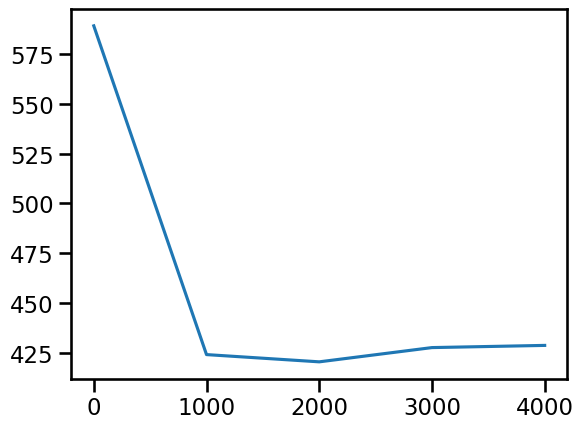

In [8]:
# #------------------------------------------------------------------------------------------------------------------------------------
# # NOTE: Number of latent dimensions, key hyper-parameter, 20~30 works for most of the cases.
K = 50
lamb = 0.01 
T = 4000     
interval = 1000
batch_size = 0.1
lr = 1e-2
seed = 0
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# #------------------------------------------------------------------------------------------------------------------------------------

start_time = time.time()
model = scmomat.scmomat_model(counts = counts, K = K, batch_size = batch_size, interval = interval, lr = lr, lamb = lamb, seed = seed, device = device)
losses = model.train_func(T = T)
end_time = time.time()
print("running time: " + str(end_time - start_time))

x = np.linspace(0, T, int(T/interval)+1)
plt.plot(x, losses)

#### inference

In [9]:
# umap_op = UMAP(n_components = 2, n_neighbors = 30, min_dist = 0.2, random_state = 0) 
out_dir = './outputs/Embryo'
os.makedirs(out_dir, exist_ok=True)

if True:
    zs = model.extract_cell_factors()
    np.save(f'{out_dir}/zs.npy', zs)
else:
    zs = np.load(f'{out_dir}/zs.npy', allow_pickle=True)
    
# x_umap = umap_op.fit_transform(np.concatenate(zs, axis = 0))

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/numpy/lib/npyio.py:518: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.asanyarray(arr)


In [10]:
# read in the ground truth labels
# NOTE: Plot the result before post-processing
# labels = [ad_bridge_rna.obs.Combined_Clusters_annotation, ad_test1_rna.obs.Combined_Clusters_annotation, ad_test2_atac.obs.Combined_Clusters_annotation]
n_obs = [adx.n_obs for adx in [ad_sra_rna, ad_mux2_27ac, ad_mux4_rna, ad_sat_atac, ad_cut_4me3, ad_cut_27ac, ad_cut_27me]]
batches = np.repeat(['s1', 's2', 's3', 's4', 's5', 's6', 's7'], n_obs)

batches

array(['s1', 's1', 's1', ..., 's7', 's7', 's7'], dtype='<U2')

### eval results

In [11]:
ad_mosaic = sc.AnnData(np.vstack(zs), obsm={"X_emb":np.vstack(zs)})
ad_mosaic.obs_names = np.hstack([adx.obs_names for adx in [ad_sra_rna, ad_mux2_27ac, ad_mux4_rna, ad_sat_atac, ad_cut_4me3, ad_cut_27ac, ad_cut_27me]])
ad_mosaic.obs['batches'] = batches

### after batch corr

In [12]:
from batchCorr import HARMONY

ad_mosaic.obsm['X_emb_har'] = HARMONY(pd.DataFrame(ad_mosaic.obsm['X_emb']), ad_mosaic.obs['batches'].to_list())
# ad_mosaic = get_umap(ad_mosaic, ['X_emb_har'])
# split_ob([ad_bridge_rna, ad_test1_rna, ad_test2_atac], ad_mosaic, ob='obsm', key='X_emb_har')

Use GPU mode.
	Initialization is completed.
	Completed 1 / 10 iteration(s).
	Completed 2 / 10 iteration(s).
	Completed 3 / 10 iteration(s).
	Completed 4 / 10 iteration(s).
	Completed 5 / 10 iteration(s).
	Completed 6 / 10 iteration(s).
	Completed 7 / 10 iteration(s).
	Completed 8 / 10 iteration(s).
Reach convergence after 8 iteration(s).


### Vis

In [13]:
anal_dir = f'../../../results/embeddings/CLUE/Embryo'
os.makedirs(anal_dir, exist_ok=True)

df = pd.DataFrame(ad_mosaic.obsm['X_emb_har'], index=ad_mosaic.obs_names)
df.to_csv(join(anal_dir, 'df_emb.csv'))